# 🏢 Building Facility Load Forecasting — 1-Hour Ahead Prediction
**Model:** LightGBM  
**Target:** `facility_load_1h` — total facility load 60 minutes ahead  
**Data sources:** InfluxDB — `inverter` · `energy_meter` · `hvac` · `environment`

In [1]:
# ─────────────────────────────────────────────────────────────
# CELL 1 — Imports and InfluxDB Connection
# ─────────────────────────────────────────────────────────────

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import requests
import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
from dotenv import load_dotenv
import ssl
import certifi

from influxdb_client import InfluxDBClient
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

load_dotenv()
# 1. Create a clean SSL context using certifi's bundle
ssl_context = ssl.create_default_context(cafile=certifi.where())

# ── InfluxDB connection settings ──────────────────────────────
INFLUX_URL    = "https://influx.htetarkar.online"
INFLUX_TOKEN  = os.getenv("influxdb_token")           # ← fill in your token
INFLUX_ORG    = "essco"
INFLUX_BUCKET = "essco_energy_data"

client    = InfluxDBClient(url=INFLUX_URL, token=INFLUX_TOKEN, org=INFLUX_ORG, ssl_context=ssl_context)
query_api = client.query_api()

print("✅ InfluxDB client initialised")
print(f"   URL    : {INFLUX_URL}")
print(f"   Org    : {INFLUX_ORG}")
print(f"   Bucket : {INFLUX_BUCKET}")

✅ InfluxDB client initialised
   URL    : https://influx.htetarkar.online
   Org    : essco
   Bucket : essco_energy_data


In [2]:
# ─────────────────────────────────────────────────────────────
# CELL 2 — Query Inverter Data
# ─────────────────────────────────────────────────────────────

inverter_query = """
from(bucket: "essco_energy_data")
  |> range(start: -30d)
  |> filter(fn: (r) => r["_measurement"] == "inverter")
  |> filter(fn: (r) => r["siteId"] == "ESSCO_49453AB5")
  |> filter(fn: (r) =>
       r["_field"] == "ac_power_phase_a" or
       r["_field"] == "ac_power_phase_b" or
       r["_field"] == "ac_power_phase_c")
  |> pivot(rowKey: ["_time"], columnKey: ["_field"], valueColumn: "_value")
  |> keep(columns: ["_time", "ac_power_phase_a", "ac_power_phase_b", "ac_power_phase_c"])
"""

raw = query_api.query_data_frame(inverter_query)
df_inverter = pd.concat(raw, ignore_index=True) if isinstance(raw, list) else raw.copy()
df_inverter = df_inverter.rename(columns={"_time": "timestamp"})

keep = [c for c in ["timestamp", "ac_power_phase_a", "ac_power_phase_b", "ac_power_phase_c"] if c in df_inverter.columns]
df_inverter = df_inverter[keep]

print(f"✅ Inverter data loaded  → shape: {df_inverter.shape}")
print(f"   Date range: {df_inverter['timestamp'].min()}  →  {df_inverter['timestamp'].max()}")
df_inverter.head(3)

✅ Inverter data loaded  → shape: (1094, 4)
   Date range: 2026-05-29 05:49:35+00:00  →  2026-06-12 07:20:26+00:00


,timestamp,ac_power_phase_a,ac_power_phase_b,ac_power_phase_c
0,2026-05-29 05:49:35+00:00,708.90,711.60,705.3
1,2026-05-29 05:50:35+00:00,708.90,715.80,705.0
2,2026-05-29 05:51:35+00:00,638.01,643.95,634.5


In [3]:
# ─────────────────────────────────────────────────────────────
# CELL 3 — Query Meter Data
# ─────────────────────────────────────────────────────────────

meter_query = """
from(bucket: "essco_energy_data")
  |> range(start: -30d)
  |> filter(fn: (r) => r["_measurement"] == "energy_meter")
  |> filter(fn: (r) => r["siteId"] == "ESSCO1")
  |> filter(fn: (r) => r["model"] == "ESSCO3P")
  |> filter(fn: (r) => r["_field"] == "active_power_total")
  |> pivot(rowKey: ["_time"], columnKey: ["_field"], valueColumn: "_value")
  |> keep(columns: ["_time", "active_power_total"])
"""

raw = query_api.query_data_frame(meter_query)
df_meter = pd.concat(raw, ignore_index=True) if isinstance(raw, list) else raw.copy()
df_meter = df_meter.rename(columns={"_time": "timestamp", "active_power_total": "meter_active_power_total"})

keep = [c for c in ["timestamp", "meter_active_power_total"] if c in df_meter.columns]
df_meter = df_meter[keep]

print(f"✅ Meter data loaded  → shape: {df_meter.shape}")
print(f"   Date range: {df_meter['timestamp'].min()}  →  {df_meter['timestamp'].max()}")
df_meter.head(3)

✅ Meter data loaded  → shape: (475, 2)
   Date range: 2026-05-29 05:43:35+00:00  →  2026-06-12 07:19:42+00:00


,timestamp,meter_active_power_total
0,2026-05-29 05:43:35+00:00,2872.0
1,2026-05-29 05:50:40+00:00,2040.0
2,2026-05-29 05:53:02+00:00,1966.0


In [4]:
# ─────────────────────────────────────────────────────────────
# CELL 4 — Query HVAC Data
# ─────────────────────────────────────────────────────────────

hvac_query = """
from(bucket: "essco_energy_data")
  |> range(start: -30d)
  |> filter(fn: (r) => r["_measurement"] == "hvac")
  |> filter(fn: (r) => r["siteId"] == "ESSCO1")
  |> filter(fn: (r) =>
       r["_field"] == "set_temperature_celsius"    or
       r["_field"] == "return_air_temperature_celsius" or
       r["_field"] == "power_state")
  |> pivot(rowKey: ["_time"], columnKey: ["_field"], valueColumn: "_value")
  |> keep(columns: ["_time", "set_temperature_celsius", "return_air_temperature_celsius", "power_state"])
"""

raw = query_api.query_data_frame(hvac_query)
df_hvac = pd.concat(raw, ignore_index=True) if isinstance(raw, list) else raw.copy()
df_hvac = df_hvac.rename(columns={"_time": "timestamp"})

keep = [c for c in ["timestamp", "set_temperature_celsius", "return_air_temperature_celsius", "power_state"] if c in df_hvac.columns]
df_hvac = df_hvac[keep]

print(f"✅ HVAC data loaded  → shape: {df_hvac.shape}")
print(f"   Date range: {df_hvac['timestamp'].min()}  →  {df_hvac['timestamp'].max()}")
df_hvac.head(3)

✅ HVAC data loaded  → shape: (478, 4)
   Date range: 2026-05-29 05:50:46+00:00  →  2026-06-12 07:22:10+00:00


,timestamp,set_temperature_celsius,return_air_temperature_celsius,power_state
0,2026-05-29 05:50:46+00:00,25.0,31.0,0.0
1,2026-05-29 05:53:08+00:00,25.0,31.0,0.0
2,2026-05-29 05:55:30+00:00,25.0,31.0,0.0


In [5]:
# ─────────────────────────────────────────────────────────────
# CELL 5 — Query Environment Data
# ─────────────────────────────────────────────────────────────

env_query = """
from(bucket: "essco_energy_data")
  |> range(start: -30d)
  |> filter(fn: (r) => r["_measurement"] == "environment")
  |> filter(fn: (r) => r["siteId"] == "ESSCO1")
  |> filter(fn: (r) => r["_field"] == "ambient_temperature_celsius")
  |> pivot(rowKey: ["_time"], columnKey: ["_field"], valueColumn: "_value")
  |> keep(columns: ["_time", "ambient_temperature_celsius"])
"""

raw = query_api.query_data_frame(env_query)
df_environment = pd.concat(raw, ignore_index=True) if isinstance(raw, list) else raw.copy()
df_environment = df_environment.rename(columns={"_time": "timestamp"})

keep = [c for c in ["timestamp", "ambient_temperature_celsius"] if c in df_environment.columns]
df_environment = df_environment[keep]

print(f"✅ Environment data loaded  → shape: {df_environment.shape}")
print(f"   Date range: {df_environment['timestamp'].min()}  →  {df_environment['timestamp'].max()}")
df_environment.head(3)

✅ Environment data loaded  → shape: (478, 2)
   Date range: 2026-05-29 05:50:00+00:00  →  2026-06-12 07:21:24+00:00


,timestamp,ambient_temperature_celsius
0,2026-05-29 05:50:00+00:00,32.4
1,2026-05-29 05:52:22+00:00,32.4
2,2026-05-29 05:54:44+00:00,32.4


In [6]:
# ─────────────────────────────────────────────────────────────
# CELL 6 — Resample All Sources to 5-Minute Grid
# ─────────────────────────────────────────────────────────────

def to_utc_index(df: pd.DataFrame, ts_col: str = "timestamp") -> pd.DataFrame:
    """Convert a timestamp column to a UTC-aware DatetimeIndex."""
    df = df.copy()
    df[ts_col] = pd.to_datetime(df[ts_col])
    if df[ts_col].dt.tz is None:
        df[ts_col] = df[ts_col].dt.tz_localize("UTC")
    else:
        df[ts_col] = df[ts_col].dt.tz_convert("UTC")
    return df.set_index(ts_col).sort_index()


# ── 1. Inverter — 5-min mean ───────────────────────────────────
df_inverter = to_utc_index(df_inverter)
df_inverter = df_inverter.resample("5min").mean()
print(f"✅ df_inverter     resampled → {df_inverter.shape}")

# ── 2. Meter — 5-min mean ─────────────────────────────────────
df_meter = to_utc_index(df_meter)
df_meter = df_meter.resample("5min").mean()
print(f"✅ df_meter        resampled → {df_meter.shape}")

# ── 3. HVAC — 5-min mean + forward fill (state changes slowly) ─
df_hvac = to_utc_index(df_hvac)
df_hvac = df_hvac.resample("5min").mean().ffill()
print(f"✅ df_hvac         resampled → {df_hvac.shape}")

# ── 4. Environment — 5-min mean + time interpolation ──────────
df_environment = to_utc_index(df_environment)
df_environment = df_environment.resample("5min").mean().interpolate(method="time")
print(f"✅ df_environment  resampled → {df_environment.shape}")

print("\n📋 All sources aligned to 5-minute UTC grid")

✅ df_inverter     resampled → (4052, 3)
✅ df_meter        resampled → (4052, 1)
✅ df_hvac         resampled → (4051, 3)
✅ df_environment  resampled → (4051, 1)

📋 All sources aligned to 5-minute UTC grid


In [7]:
# ─────────────────────────────────────────────────────────────
# CELL 7 — Engineer Inverter Total and Facility Load
# ─────────────────────────────────────────────────────────────

# Step 1: Sum three inverter phases → inverter AC total
df_inverter["inverter_ac_power_total"] = (
    df_inverter["ac_power_phase_a"].fillna(0)
    + df_inverter["ac_power_phase_b"].fillna(0)
    + df_inverter["ac_power_phase_c"].fillna(0)
)

# Step 2: Align meter and inverter on common index for the subtraction
combined = df_inverter[["inverter_ac_power_total"]].join(
    df_meter[["meter_active_power_total"]], how="inner"
)

# Step 3: Facility load = grid import + solar export contribution
#         active_power_total from the meter already measures net grid power;
#         adding the inverter output gives total facility consumption.
combined["facility_load"] = (
    combined["meter_active_power_total"]
    + combined["inverter_ac_power_total"]
)

# Keep only facility_load for downstream merging
df_load = combined[["facility_load"]]

print(f"✅ facility_load engineered → shape: {df_load.shape}")
print(f"   Min  : {df_load['facility_load'].min():.1f} W")
print(f"   Max  : {df_load['facility_load'].max():.1f} W")
print(f"   Mean : {df_load['facility_load'].mean():.1f} W")
df_load.head(3)

✅ facility_load engineered → shape: (4051, 1)
   Min  : 0.0 W
   Max  : 16455.2 W
   Mean : 6632.2 W


,facility_load
timestamp,
2026-05-29 05:45:00+00:00,NaN
2026-05-29 05:50:00+00:00,4075.036
2026-05-29 05:55:00+00:00,4600.842


In [8]:
# ─────────────────────────────────────────────────────────────
# CELL 8 — Join All DataFrames (Inner Join)
# ─────────────────────────────────────────────────────────────

# Inner join: only keep timestamps present in ALL four sources
df = (
    df_load
    .join(df_hvac,        how="inner")
    .join(df_environment, how="inner")
)

print(f"✅ Joined dataset → shape: {df.shape}")
print(f"   Date range : {df.index.min()}  →  {df.index.max()}")
print(f"   Columns    : {list(df.columns)}")
df.head(3)

✅ Joined dataset → shape: (4050, 5)
   Date range : 2026-05-29 05:50:00+00:00  →  2026-06-12 07:15:00+00:00
   Columns    : ['facility_load', 'set_temperature_celsius', 'return_air_temperature_celsius', 'power_state', 'ambient_temperature_celsius']


,facility_load,set_temperature_celsius,return_air_temperature_celsius,power_state,ambient_temperature_celsius
timestamp,,,,,
2026-05-29 05:50:00+00:00,4075.036000,25.0,31.000000,0.000000,32.40
2026-05-29 05:55:00+00:00,4600.842000,25.0,31.000000,0.000000,32.45
2026-05-29 06:00:00+00:00,5257.044667,25.0,31.333333,0.666667,32.35


In [9]:
# ─────────────────────────────────────────────────────────────
# CELL 9 — Create Lag Features
# ─────────────────────────────────────────────────────────────

LAG_STEPS = [1, 2, 3, 4, 6, 12]

for lag in LAG_STEPS:
    df[f"lag_{lag}"] = df["facility_load"].shift(lag)

print(f"✅ Lag features created: {[f'lag_{l}' for l in LAG_STEPS]}")
df[["facility_load"] + [f"lag_{l}" for l in LAG_STEPS]].head(15)

✅ Lag features created: ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_6', 'lag_12']


,facility_load,lag_1,lag_2,lag_3,lag_4,lag_6,lag_12
timestamp,,,,,,,
2026-05-29 05:50:00+00:00,4075.036000,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-29 05:55:00+00:00,4600.842000,4075.036000,NaN,NaN,NaN,NaN,NaN
2026-05-29 06:00:00+00:00,5257.044667,4600.842000,4075.036000,NaN,NaN,NaN,NaN
2026-05-29 06:05:00+00:00,11344.864000,5257.044667,4600.842000,4075.036000,NaN,NaN,NaN
2026-05-29 06:10:00+00:00,9626.392500,11344.864000,5257.044667,4600.842000,4075.036000,NaN,NaN
2026-05-29 06:15:00+00:00,NaN,9626.392500,11344.864000,5257.044667,4600.842000,NaN,NaN
2026-05-29 06:20:00+00:00,NaN,NaN,9626.392500,11344.864000,5257.044667,4075.036000,NaN
2026-05-29 06:25:00+00:00,NaN,NaN,NaN,9626.392500,11344.864000,4600.842000,NaN
2026-05-29 06:30:00+00:00,NaN,NaN,NaN,NaN,9626.392500,5257.044667,NaN


In [10]:
# ─────────────────────────────────────────────────────────────
# CELL 10 — Create Rolling Features
# ─────────────────────────────────────────────────────────────

WINDOW = 6

df["rolling_mean_6"] = df["facility_load"].rolling(window=WINDOW).mean()
df["rolling_std_6"]  = df["facility_load"].rolling(window=WINDOW).std()

print(f"✅ Rolling features created (window={WINDOW}): rolling_mean_6, rolling_std_6")
df[["facility_load", "rolling_mean_6", "rolling_std_6"]].head(10)

✅ Rolling features created (window=6): rolling_mean_6, rolling_std_6


,facility_load,rolling_mean_6,rolling_std_6
timestamp,,,
2026-05-29 05:50:00+00:00,4075.036000,NaN,NaN
2026-05-29 05:55:00+00:00,4600.842000,NaN,NaN
2026-05-29 06:00:00+00:00,5257.044667,NaN,NaN
2026-05-29 06:05:00+00:00,11344.864000,NaN,NaN
2026-05-29 06:10:00+00:00,9626.392500,NaN,NaN
2026-05-29 06:15:00+00:00,NaN,NaN,NaN
2026-05-29 06:20:00+00:00,NaN,NaN,NaN
2026-05-29 06:25:00+00:00,NaN,NaN,NaN
2026-05-29 06:30:00+00:00,NaN,NaN,NaN


In [11]:
# ─────────────────────────────────────────────────────────────
# CELL 11 — Create Time Features (Asia/Bangkok)
# ─────────────────────────────────────────────────────────────

LOCAL_TZ = "Asia/Bangkok"

local_index = df.index.tz_convert(LOCAL_TZ)

df["hour_of_day"] = local_index.hour
df["day_of_week"] = local_index.dayofweek   # Monday=0, Sunday=6

print(f"✅ Time features created (timezone: {LOCAL_TZ})")
print(f"   hour_of_day → unique: {sorted(df['hour_of_day'].unique())}")
print(f"   day_of_week → unique: {sorted(df['day_of_week'].unique())}")
df[["hour_of_day", "day_of_week"]].head(5)

✅ Time features created (timezone: Asia/Bangkok)
   hour_of_day → unique: [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22), np.int32(23)]
   day_of_week → unique: [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6)]


,hour_of_day,day_of_week
timestamp,,
2026-05-29 05:50:00+00:00,12,4
2026-05-29 05:55:00+00:00,12,4
2026-05-29 06:00:00+00:00,13,4
2026-05-29 06:05:00+00:00,13,4
2026-05-29 06:10:00+00:00,13,4


In [12]:
# ─────────────────────────────────────────────────────────────
# CELL 12 — Create Target Variable
# ─────────────────────────────────────────────────────────────

# 12 steps × 5 minutes = 60 minutes ahead
TARGET_SHIFT = 12

df["facility_load_1h"] = df["facility_load"].shift(-TARGET_SHIFT)

print(f"✅ Target created: facility_load_1h = facility_load.shift(-{TARGET_SHIFT})")
print(f"   Non-null values: {df['facility_load_1h'].notna().sum()} / {len(df)}")
df[["facility_load", "facility_load_1h"]].tail(20)

✅ Target created: facility_load_1h = facility_load.shift(-12)
   Non-null values: 222 / 4050


,facility_load,facility_load_1h
timestamp,,
2026-06-12 05:40:00+00:00,6239.040000,14733.078000
2026-06-12 05:45:00+00:00,9988.978000,10640.248000
2026-06-12 05:50:00+00:00,8874.029333,5837.178000
2026-06-12 05:55:00+00:00,6269.966667,5361.006000
2026-06-12 06:00:00+00:00,5743.158000,5754.350000
2026-06-12 06:05:00+00:00,5568.772000,4906.970000
2026-06-12 06:10:00+00:00,7663.326000,4400.572667
2026-06-12 06:15:00+00:00,8578.968000,4866.000000
2026-06-12 06:20:00+00:00,6932.608000,NaN


In [13]:
# ─────────────────────────────────────────────────────────────
# CELL 13 — Drop NaN Rows
# ─────────────────────────────────────────────────────────────

shape_before = df.shape
print(f"Shape BEFORE dropping NaNs : {shape_before}")

df = df.dropna()

shape_after = df.shape
print(f"Shape AFTER  dropping NaNs : {shape_after}")
print(f"Rows removed               : {shape_before[0] - shape_after[0]}")
print()
print("Remaining NaN counts per column:")
print(df.isnull().sum())

Shape BEFORE dropping NaNs : (4050, 16)
Shape AFTER  dropping NaNs : (79, 16)
Rows removed               : 3971

Remaining NaN counts per column:
facility_load                     0
set_temperature_celsius           0
return_air_temperature_celsius    0
power_state                       0
ambient_temperature_celsius       0
lag_1                             0
lag_2                             0
lag_3                             0
lag_4                             0
lag_6                             0
lag_12                            0
rolling_mean_6                    0
rolling_std_6                     0
hour_of_day                       0
day_of_week                       0
facility_load_1h                  0
dtype: int64


df.shape   : (79, 16)

── dtypes ──────────────────────────────────
facility_load                     float64
set_temperature_celsius           float64
return_air_temperature_celsius    float64
power_state                       float64
ambient_temperature_celsius       float64
lag_1                             float64
lag_2                             float64
lag_3                             float64
lag_4                             float64
lag_6                             float64
lag_12                            float64
rolling_mean_6                    float64
rolling_std_6                     float64
hour_of_day                         int32
day_of_week                         int32
facility_load_1h                  float64
dtype: object

── null counts ─────────────────────────────
facility_load                     0
set_temperature_celsius           0
return_air_temperature_celsius    0
power_state                       0
ambient_temperature_celsius       0
lag_1               

,facility_load,set_temperature_celsius,return_air_temperature_celsius,power_state,ambient_temperature_celsius,lag_1,lag_2,lag_3,lag_4,lag_6,lag_12,rolling_mean_6,rolling_std_6,hour_of_day,day_of_week,facility_load_1h
count,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000
mean,6152.793367,22.151899,28.729958,0.613924,29.495570,6364.898561,6573.794352,6637.430302,6758.453745,6561.606194,7046.968025,6530.741984,1554.950614,14.151899,2.810127,5569.849314
std,4028.617649,0.661944,1.427823,0.486677,0.726183,4151.293861,4289.237980,4271.209985,4347.931801,4305.357823,4886.878701,3817.269204,1268.020855,2.413045,1.199102,4010.973646
min,0.000000,22.000000,27.000000,0.000000,28.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11.000000,1.000000,0.000000
25%,3944.993000,22.000000,27.000000,0.000000,29.075000,3902.922000,3847.140000,3864.491000,3844.271000,3236.790000,2946.963417,4325.405722,621.324669,12.500000,2.000000,2564.973333
50%,5602.882000,22.000000,29.000000,1.000000,29.650000,5759.900000,5975.862000,6149.748000,6239.040000,6051.848000,6539.896000,7351.371667,1343.412990,14.000000,2.000000,4964.214000
75%,8751.975667,22.000000,30.000000,1.000000,29.925000,9910.574000,10314.591000,10207.975000,10314.591000,10096.509000,11186.558250,9172.120861,2457.288970,15.000000,4.000000,8129.012333
max,16211.225000,25.000000,31.000000,1.000000,31.100000,15298.556000,15298.556000,15298.556000,15298.556000,15298.556000,16455.182000,13217.080611,4946.274236,19.000000,4.000000,14733.078000


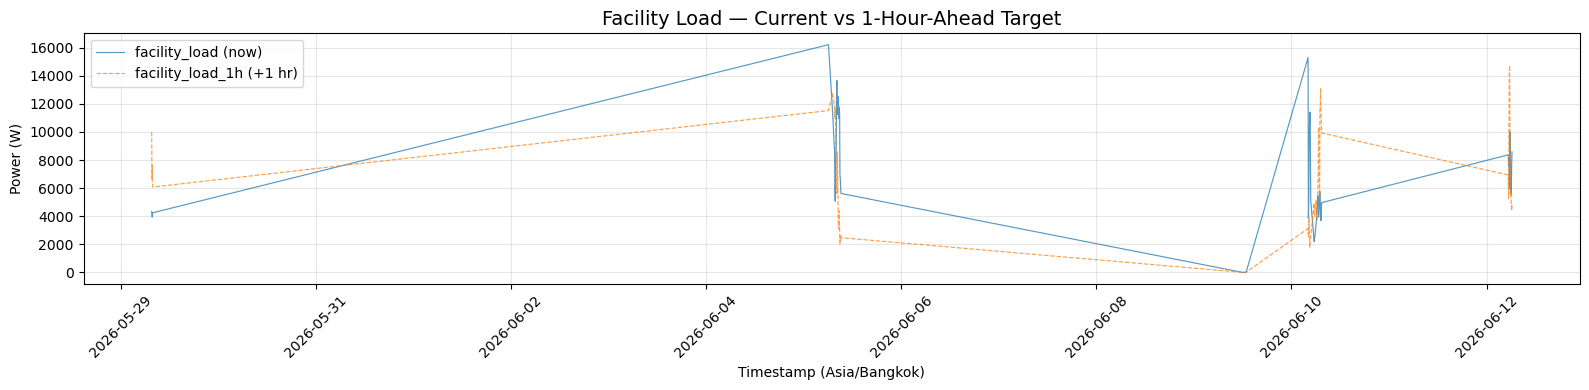

In [14]:
# ─────────────────────────────────────────────────────────────
# CELL 14 — Exploratory Check
# ─────────────────────────────────────────────────────────────

print("=" * 60)
print(f"df.shape   : {df.shape}")
print("=" * 60)

print("\n── dtypes ──────────────────────────────────")
print(df.dtypes)

print("\n── null counts ─────────────────────────────")
print(df.isnull().sum())

print("\n── describe ────────────────────────────────")
display(df.describe())

# ── Plot facility_load vs facility_load_1h ─────────────────────
fig, ax = plt.subplots(figsize=(16, 4))

local_ts = df.index.tz_convert("Asia/Bangkok")

ax.plot(local_ts, df["facility_load"],    label="facility_load (now)",    alpha=0.75, linewidth=0.85)
ax.plot(local_ts, df["facility_load_1h"], label="facility_load_1h (+1 hr)", alpha=0.75, linewidth=0.85, linestyle="--")

ax.set_title("Facility Load — Current vs 1-Hour-Ahead Target", fontsize=14)
ax.set_xlabel("Timestamp (Asia/Bangkok)")
ax.set_ylabel("Power (W)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.xticks(rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
# ─────────────────────────────────────────────────────────────
# CELL 15 — Train / Validation Split (Chronological 80/20)
# ─────────────────────────────────────────────────────────────

FEATURES = [
    # Lag features (6)
    "lag_1", "lag_2", "lag_3", "lag_4", "lag_6", "lag_12",
    # Rolling features (2)
    "rolling_mean_6", "rolling_std_6",
    # HVAC features (3)
    "set_temperature_celsius", "return_air_temperature_celsius", "power_state",
    # Environment feature (1)
    "ambient_temperature_celsius",
    # Time features (2)
    "hour_of_day", "day_of_week",
]

TARGET = "facility_load_1h"

# Verify all features are present
missing = [f for f in FEATURES if f not in df.columns]
if missing:
    print(f"⚠️  Missing features: {missing}")
else:
    print(f"✅ All {len(FEATURES)} features present")

# Chronological split — no shuffling
split_idx = int(len(df) * 0.8)

df_train = df.iloc[:split_idx]
df_val   = df.iloc[split_idx:]

X_train = df_train[FEATURES]
y_train = df_train[TARGET]
X_val   = df_val[FEATURES]
y_val   = df_val[TARGET]

print(f"\nTotal rows   : {len(df):,}")
print(f"Train rows   : {len(df_train):,}  ({len(df_train)/len(df)*100:.1f}%)")
print(f"Val rows     : {len(df_val):,}  ({len(df_val)/len(df)*100:.1f}%)")
print(f"Feature count: {len(FEATURES)}")

✅ All 14 features present

Total rows   : 79
Train rows   : 63  (79.7%)
Val rows     : 16  (20.3%)
Feature count: 14


In [16]:
# ─────────────────────────────────────────────────────────────
# CELL 16 — Train LightGBM Model
# ─────────────────────────────────────────────────────────────

params = {
    "objective"    : "regression",
    "metric"       : "rmse",
    "learning_rate": 0.05,
    "num_leaves"   : 31,
    "n_estimators" : 500,
    "verbosity"    : -1,
    "random_state" : 42,
}

model = lgb.LGBMRegressor(**params)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        lgb.log_evaluation(period=50),
    ],
)

print(f"\n✅ Training complete")
print(f"   Best iteration : {model.best_iteration_}")
print(f"   Best val RMSE  : {model.best_score_['valid_0']['rmse']:.2f} W")

Training until validation scores don't improve for 50 rounds
[50]	valid_0's rmse: 4687.93
[100]	valid_0's rmse: 4474.56
[150]	valid_0's rmse: 4266.01
[200]	valid_0's rmse: 4211.15
[250]	valid_0's rmse: 4224.51
Early stopping, best iteration is:
[207]	valid_0's rmse: 4205.4

✅ Training complete
   Best iteration : 207
   Best val RMSE  : 4205.40 W


  Validation Metrics (Facility Load)
  RMSE : 4,205.40 W
  MAE  : 3,529.12 W


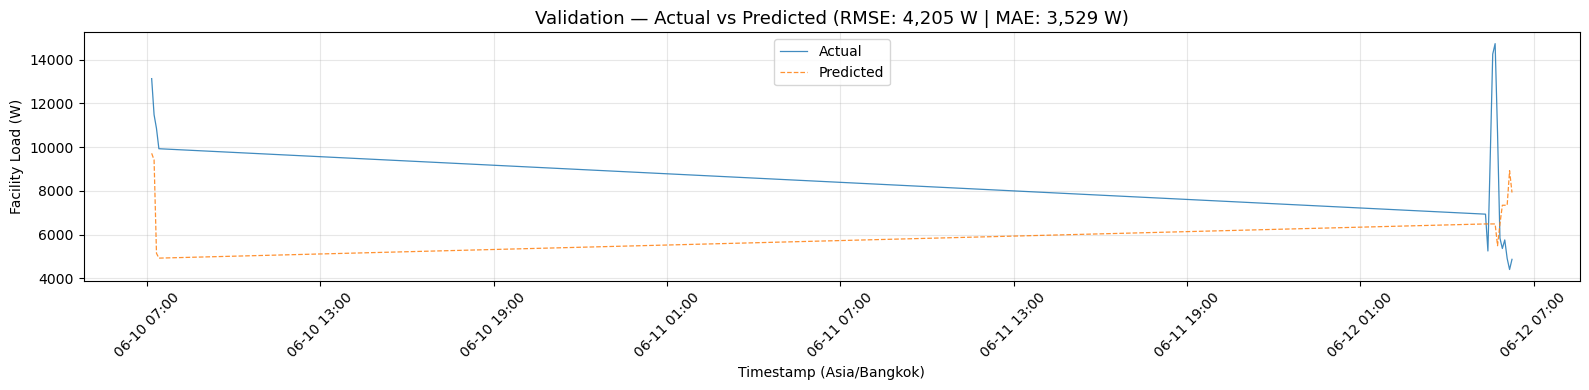

In [17]:
# ─────────────────────────────────────────────────────────────
# CELL 17 — Evaluate Model on Validation Set
# ─────────────────────────────────────────────────────────────

y_pred = model.predict(X_val)

rmse = root_mean_squared_error(y_val, y_pred)
mae  = mean_absolute_error(y_val, y_pred)

print("=" * 40)
print("  Validation Metrics (Facility Load)")
print("=" * 40)
print(f"  RMSE : {rmse:,.2f} W")
print(f"  MAE  : {mae:,.2f} W")
print("=" * 40)

# ── Actual vs Predicted plot ───────────────────────────────────
val_local_ts = df_val.index.tz_convert("Asia/Bangkok")
plot_n = min(len(df_val), 12 * 24 * 3)   # up to 3 days of 5-min data

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(val_local_ts[:plot_n], y_val.values[:plot_n], label="Actual",    linewidth=0.9, alpha=0.85)
ax.plot(val_local_ts[:plot_n], y_pred[:plot_n],       label="Predicted", linewidth=0.9, alpha=0.85, linestyle="--")

ax.set_title(f"Validation — Actual vs Predicted (RMSE: {rmse:,.0f} W | MAE: {mae:,.0f} W)", fontsize=13)
ax.set_xlabel("Timestamp (Asia/Bangkok)")
ax.set_ylabel("Facility Load (W)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
plt.xticks(rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

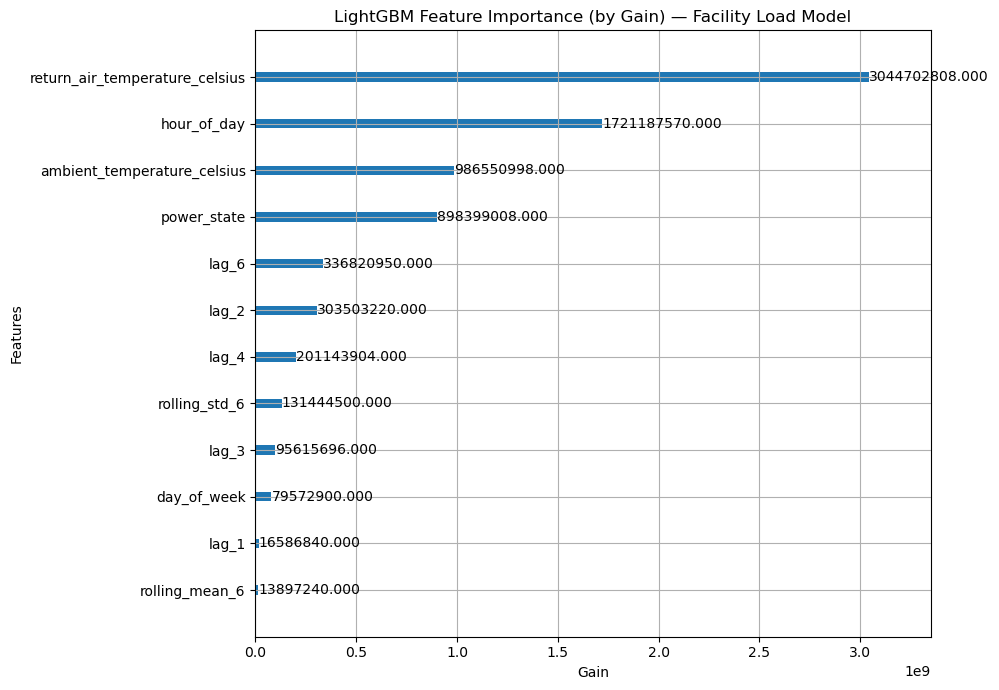


── Feature Importances (gain) ──────────────


,feature,importance
0,hour_of_day,117
1,lag_6,49
2,ambient_temperature_celsius,24
3,return_air_temperature_celsius,21
4,lag_2,17
5,rolling_std_6,7
6,day_of_week,6
7,power_state,4
8,lag_1,4
9,lag_4,2



💡 Interpretation tips:
   • High lag/rolling importance → load is strongly auto-regressive
   • High HVAC importance (power_state / return_air_temp) → HVAC drives load spikes
   • High ambient_temperature_celsius importance → outdoor temp correlates with cooling demand
   • Low-importance features → candidates for removal in next iteration


In [18]:
# ─────────────────────────────────────────────────────────────
# CELL 18 — Feature Importance
# ─────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 7))
lgb.plot_importance(
    model,
    ax=ax,
    importance_type="gain",
    max_num_features=len(FEATURES),
    title="LightGBM Feature Importance (by Gain) — Facility Load Model",
    xlabel="Gain",
)
plt.tight_layout()
plt.show()

# ── Tabular view ───────────────────────────────────────────────
importance_df = pd.DataFrame({
    "feature"   : model.feature_name_,
    "importance": model.feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)

print("\n── Feature Importances (gain) ──────────────")
display(importance_df)

print("\n💡 Interpretation tips:")
print("   • High lag/rolling importance → load is strongly auto-regressive")
print("   • High HVAC importance (power_state / return_air_temp) → HVAC drives load spikes")
print("   • High ambient_temperature_celsius importance → outdoor temp correlates with cooling demand")
print("   • Low-importance features → candidates for removal in next iteration")